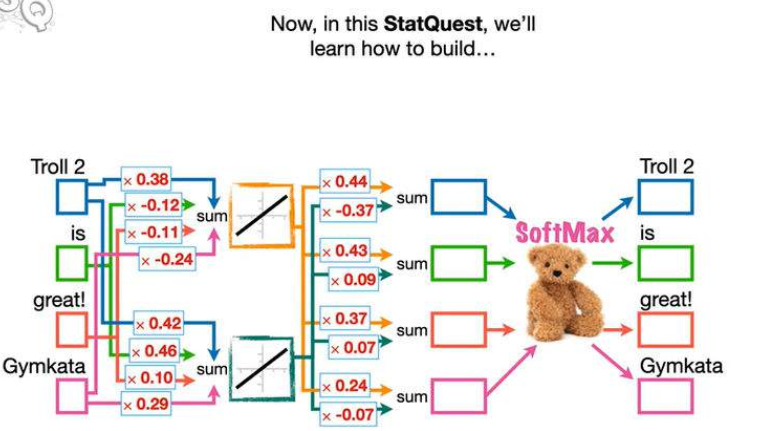

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.distributions.uniform import Uniform
import lightning as L

In [3]:
import pandas

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

Training Data

Troll2 is great

Gymkata is great

In [6]:
# Troll2, is, great, Gymkata
inputs = torch.tensor([[1.,0.,0.,0.],
                       [0.,1.,0.,0.],
                       [0.,0.,1.,0.],
                       [0.,0.,0.,1.]])

labels = torch.tensor([[0.,1.,0.,0.],
                      [0.,0.,1.,0.],
                      [0.,0.,0.,1.],
                      [0.,1.,0.,0.]])

In [7]:
dataset = TensorDataset(inputs,labels)
dataloader = DataLoader(dataset)

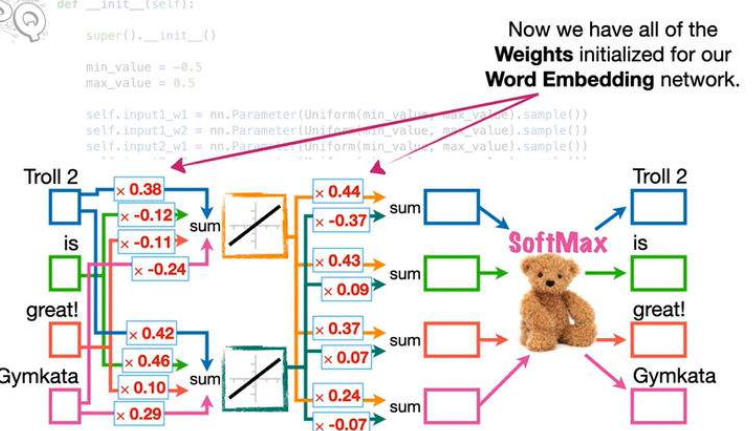

In [9]:
class WordEmbeddingFromScratch(L.LightningModule):
    def __init__(self):
        super().__init__()
        min_value = -0.5
        max_value = 0.5
        self.input1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.input4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.output1_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output1_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output2_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output3_w2 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w1 = nn.Parameter(Uniform(min_value, max_value).sample())
        self.output4_w2 = nn.Parameter(Uniform(min_value, max_value).sample())

        self.loss = nn.CrossEntropyLoss()
    def forward(self,input):
        inputs_to_top_hidden = ((input[0]*self.input1_w1)+
                               (input[1]*self.input2_w1)+
                               (input[2]*self.input3_w1)+
                               (input[3]*self.input4_w1))
        inputs_to_bottom_hidden = ((input[0]*self.input1_w2)+
                                  (input[1]*self.input2_w2)+
                                  (input[2]*self.input3_w2)+
                                  (input[3]*self.input4_w2))
        output1 = ((inputs_to_top_hidden * self.output1_w1)+
                  (inputs_to_bottom_hidden * self.output1_w2))
        output2 = ((inputs_to_top_hidden * self.output2_w1)+
                  (inputs_to_bottom_hidden * self.output2_w2))
        output3 = ((inputs_to_top_hidden * self.output3_w1)+
                  (inputs_to_bottom_hidden * self.output3_w2))
        output4 = ((inputs_to_top_hidden * self.output4_w1)+
                  (inputs_to_bottom_hidden * self.output4_w2))
        output_presoftmax = torch.stack([output1, output2, output3, output4])
        return (output_presoftmax)
    def configure_optimizers(self):
        return Adam(self.parameters(), lr=0.1)
    def training_step(self, batch,batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = self.loss(output_i, label_i[0])
        return loss

In [10]:
model0 = WordEmbeddingFromScratch()

In [11]:
print("Before optimization, the parameters are ...")
for name, param in model0.named_parameters():
    print(name, param.data)

Before optimization, the parameters are ...
input1_w1 tensor(-0.0674)
input1_w2 tensor(-0.4631)
input2_w1 tensor(-0.3602)
input2_w2 tensor(0.2193)
input3_w1 tensor(0.3806)
input3_w2 tensor(-0.1975)
input4_w1 tensor(0.0484)
input4_w2 tensor(0.4451)
output1_w1 tensor(0.0110)
output1_w2 tensor(-0.3415)
output2_w1 tensor(0.0818)
output2_w2 tensor(0.3703)
output3_w1 tensor(-0.3136)
output3_w2 tensor(-0.3589)
output4_w1 tensor(0.1823)
output4_w2 tensor(0.3187)


In [12]:
import pandas as pd
data = {
    "w1": [model0.input1_w1.item(),
          model0.input2_w1.item(),
          model0.input3_w1.item(),
          model0.input4_w1.item()],
    "w2": [model0.input1_w2.item(),
          model0.input2_w2.item(),
          model0.input3_w2.item(),
          model0.input4_w2.item()],
    "token": ["Troll2","is","great","Gymkata"],
    "input": ["input1","input2","input3","input4"]      
}
df = pd.DataFrame(data)

In [13]:
df

,w1,w2,token,input
0,-0.067410,-0.463055,Troll2,input1
1,-0.360153,0.219257,is,input2
2,0.380581,-0.197548,great,input3
3,0.048354,0.445078,Gymkata,input4


In [14]:
import matplotlib.pyplot as plt

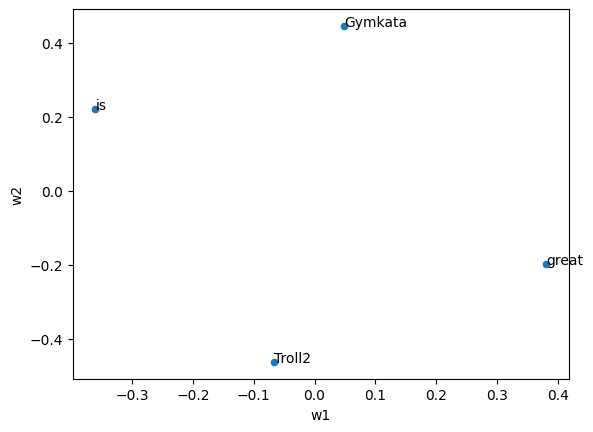

In [15]:
sns.scatterplot(data=df, x='w1',y='w2')
for i in range(0,4):
    plt.text(df.w1[i],df.w2[i],df.token[i])

In [16]:
#trainer = L.Trainer(max_epochs=200)
#trainer.fit(model0, train_dataloaders = dataloader)

In [17]:
class WordEmbeddingWithLinear(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.input_to_hidden = nn.Linear(in_features = 4, out_features = 2, bias=False)
        self.hidden_to_output = nn.Linear(in_features = 2, out_features = 4, bias=False)

        self.loss = nn.CrossEntropyLoss()
    def forward(self, input):
        hidden = self.input_to_hidden(input)
        output_values = self.hidden_to_output(hidden)
        return (output_values)
        
    def configure_optimizers(self):
        return Adam(self.parameters(), lr= 0.1)
    def training_step(self,batch,batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = self.loss(output_i, label_i)
        return loss   
        

In [18]:
modelLinear = WordEmbeddingWithLinear()

In [19]:
data = {
    'w1': modelLinear.input_to_hidden.weight.detach()[0].numpy(),
    'w2': modelLinear.input_to_hidden.weight.detach()[1].numpy(),
    'token': ['Troll2','is','great', 'Gymkata'],
    'input': ['input1', 'input2', 'input3', 'input4']
    }
df = pd.DataFrame(data)
df

,w1,w2,token,input
0,-0.057504,-0.125142,Troll2,input1
1,0.073260,-0.256676,is,input2
2,0.055583,-0.225031,great,input3
3,-0.499503,0.219233,Gymkata,input4


Text(-0.499503493309021, 0.2192327380180359, 'Gymkata')

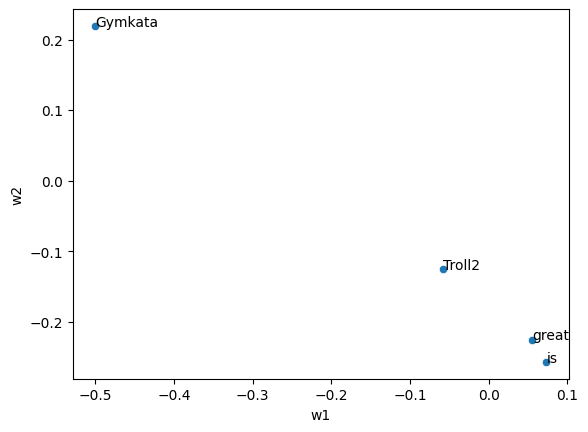

In [20]:
sns.scatterplot(data=df, x='w1',y='w2')
plt.text(df.w1[0], df.w2[0],df.token[0])
plt.text(df.w1[1], df.w2[1],df.token[1])
plt.text(df.w1[2], df.w2[2],df.token[2])
plt.text(df.w1[3], df.w2[3],df.token[3])

In [39]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(modelLinear, train_dataloaders = dataloader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type             | Params | Mode 
--------------------------------------------------------------
0 | input_to_hidden  | Linear           | 8      | train
1 | hidden_to_output | Linear           | 8      | train
2 | loss             | CrossEntropyLoss | 0      | train
--------------------------------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
C:\Users\HP\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\HP\anaconda3\Lib\site-packages\

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=100` reached.


Text(-2.948655366897583, -0.450743168592453, 'Gymkata')

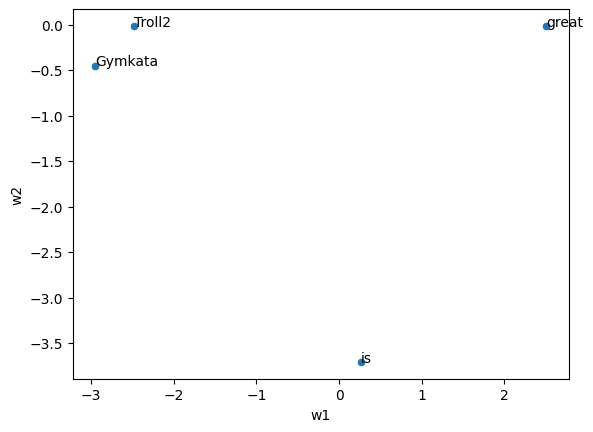

In [41]:
data = {
    'w1': modelLinear.input_to_hidden.weight.detach()[0].numpy(),
    'w2': modelLinear.input_to_hidden.weight.detach()[1].numpy(),
    'token': ['Troll2','is','great', 'Gymkata'],
    'input': ['input1', 'input2', 'input3', 'input4']
    }
df = pd.DataFrame(data)
sns.scatterplot(data=df, x='w1',y='w2')
plt.text(df.w1[0], df.w2[0],df.token[0])
plt.text(df.w1[1], df.w2[1],df.token[1])
plt.text(df.w1[2], df.w2[2],df.token[2])
plt.text(df.w1[3], df.w2[3],df.token[3])

In [43]:
modelLinear.input_to_hidden.weight

Parameter containing:
tensor([[-2.4834,  0.2590,  2.5073, -2.9487],
        [-0.0151, -3.7073, -0.0153, -0.4507]], requires_grad=True)

In [45]:
word_embeddings = nn.Embedding.from_pretrained(modelLinear.input_to_hidden.weight.T)

In [49]:
word_embeddings.weight

Parameter containing:
tensor([[-2.4834, -0.0151],
        [ 0.2590, -3.7073],
        [ 2.5073, -0.0153],
        [-2.9487, -0.4507]])

In [51]:
# embedding value for troll2
word_embeddings(torch.tensor(0))

tensor([-2.4834, -0.0151])

In [55]:
vocab = {
    'Troll2':0,
    'is':1,
    'great':2,
    'Gymkata':3
}
word_embeddings(torch.tensor(vocab['Troll2']))

tensor([-2.4834, -0.0151])

In [57]:
pip install nbconvert[webpdf]

   ---------------------------------------- 0.0/29.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/29.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/29.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/29.9 MB 435.7 kB/s eta 0:01:09
   ---------------------------------------- 0.0/29.9 MB 435.7 kB/s eta 0:01:09
   ---------------------------------------- 0.1/29.9 MB 297.7 kB/s eta 0:01:41
   ---------------------------------------- 0.1/29.9 MB 280.5 kB/s eta 0:01:47
   ---------------------------------------- 0.1/29.9 MB 348.6 kB/s eta 0:01:26
   ---------------------------------------- 0.1/29.9 MB 379.3 kB/s eta 0:01:19
   ---------------------------------------- 0.2/29.9 MB 398.2 kB/s eta 0:01:15
   ---------------------------------------- 0.2/29.9 MB 436.9 kB/s eta 0:01:09
   ---------------------------------------- 0.2/29.9 MB 491.0 kB/s eta 0:01:01
   ---------------------------------------- 0.2/29.9 MB 480.3 kB/s eta 0:01:02


In [59]:
--allow-chromium-download

NameError: name 'allow' is not defined

In [61]:
playwright install chromium

SyntaxError: invalid syntax (1470437723.py, line 1)